In [1]:
from datasets import load_dataset
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
a = {"a": 1, "b": 2, "c": 3}

In [3]:
pd.DataFrame([a])

,a,b,c
0,1,2,3


# Loading Dataset

In [4]:
dataset_path = "/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa"

ds = load_dataset(
    "duongtr/ReasonVQA",
    data_files={
        "train": f"{dataset_path}/train.jsonl",
        "validation": f"{dataset_path}/val.jsonl"
    },
    cache_dir=dataset_path
)

In [5]:
ann = load_dataset("duongtr/ReasonVQA", data_files={
    "train": f"{dataset_path}/train_ann.jsonl",
    "validation": f"{dataset_path}/val_ann.jsonl"
})

In [6]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'source', 'image_path', 'question_id', 'question', 'answers', 'correct', 'categories', 'image_url'],
        num_rows: 3085697
    })
    validation: Dataset({
        features: ['image_id', 'image_name', 'source', 'image_path', 'question_id', 'question', 'answers', 'correct', 'categories', 'image_url'],
        num_rows: 1323772
    })
})


# Data Exploration

In [7]:
train_df = pd.DataFrame(ds["train"])

In [8]:
val_df = pd.DataFrame(ds["validation"])

In [9]:
train_df

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url
0,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,0,In which country can you find this house?,"[Czech Republic, Jamaica, Singapore, Bosnia He...","[1, 0, 0, 0]","[0, 3, 8, 17]",http://upload.wikimedia.org/wikipedia/commons/...
1,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,1,What is the namesake of this house?,"[Ondřej Puklice ze Vztuh, Africa, Scotland, Hu...","[1, 0, 0, 0]",[1],http://upload.wikimedia.org/wikipedia/commons/...
2,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,2,What is the area of the landlocked country whe...,"[78866, 105015, 88335, 42200]","[1, 0, 0, 0]","[0, 6]",http://upload.wikimedia.org/wikipedia/commons/...
3,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,3,Is the country where this house is located lef...,"[right, left]","[1, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...
4,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,4,Who is the head of government of the republic ...,"[Petr Fiala, Stanley Bruce, Angela Merkel, Abd...","[1, 0, 0, 0]",[7],http://upload.wikimedia.org/wikipedia/commons/...
...,...,...,...,...,...,...,...,...,...,...
3085692,VG_2400464,VG_2400464.jpg,VG,,4481650,What is the driving side of the country where ...,"[right, left]","[1, 0]",[0],https://cs.stanford.edu/people/rak248/VG_100K_...
3085693,VG_2400464,VG_2400464.jpg,VG,,4481651,What is the name of the sovereign state where ...,[ꠃꠇ꠆ꠞꠦꠘ],[1],[1],https://cs.stanford.edu/people/rak248/VG_100K_...
3085694,VG_2400464,VG_2400464.jpg,VG,,4481652,When was the secular state where the party tha...,"[1500, 1495, 1507, 1503]","[1, 0, 0, 0]","[2, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...
3085695,VG_2400464,VG_2400464.jpg,VG,,4481653,Who invented the secular state where the party...,"[Pedro Álvares Cabral, Charles Darwin, Alan Tu...","[1, 0, 0, 0]","[1, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...


In [10]:
train_ann_df = pd.DataFrame(ann["train"])

In [11]:
val_ann_df = pd.DataFrame(ann["validation"])

In [12]:
train_ann_df

,question_id,hop,has_scene_graph,entity_id,entity_name,route,property_id,property_label
0,0,1,False,Q8310682,Puklicův dům,"[Q8310682, Q213]",P17,country
1,1,1,False,Q8310682,Puklicův dům,"[Q8310682, Q104927715]",P138,named after
2,2,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, 78866]",P2046,area
3,3,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, Q14565199]",P1622,driving side
4,4,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, Q3377548]",P6,head of government
...,...,...,...,...,...,...,...,...
3085692,4481650,3,True,Q1808937,kermesse,"[Q1808937, Q214, Q14565199]",P1622,driving side
3085693,4481651,3,True,Q1808937,kermesse,"[Q1808937, Q212, ꠃꠇ꠆ꠞꠦꠘ]",P2561,name
3085694,4481652,3,True,Q1808937,kermesse,"[Q1808937, Q155, 1500-05-02T00:00:00Z]",P575,time of discovery or invention
3085695,4481653,3,True,Q1808937,kermesse,"[Q1808937, Q155, Q174432]",P61,discoverer or inventor


In [13]:
train_merged_df = pd.merge(train_df, train_ann_df, on="question_id")

In [14]:
val_merged_df = pd.merge(val_df, val_ann_df, on="question_id")

In [15]:
train_merged_df

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url,hop,has_scene_graph,entity_id,entity_name,route,property_id,property_label
0,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,0,In which country can you find this house?,"[Czech Republic, Jamaica, Singapore, Bosnia He...","[1, 0, 0, 0]","[0, 3, 8, 17]",http://upload.wikimedia.org/wikipedia/commons/...,1,False,Q8310682,Puklicův dům,"[Q8310682, Q213]",P17,country
1,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,1,What is the namesake of this house?,"[Ondřej Puklice ze Vztuh, Africa, Scotland, Hu...","[1, 0, 0, 0]",[1],http://upload.wikimedia.org/wikipedia/commons/...,1,False,Q8310682,Puklicův dům,"[Q8310682, Q104927715]",P138,named after
2,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,2,What is the area of the landlocked country whe...,"[78866, 105015, 88335, 42200]","[1, 0, 0, 0]","[0, 6]",http://upload.wikimedia.org/wikipedia/commons/...,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, 78866]",P2046,area
3,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,3,Is the country where this house is located lef...,"[right, left]","[1, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, Q14565199]",P1622,driving side
4,GLDv2_0000059611c7d079,GLDv2_0000059611c7d079.jpg,GLDv2,,4,Who is the head of government of the republic ...,"[Petr Fiala, Stanley Bruce, Angela Merkel, Abd...","[1, 0, 0, 0]",[7],http://upload.wikimedia.org/wikipedia/commons/...,2,False,Q8310682,Puklicův dům,"[Q8310682, Q213, Q3377548]",P6,head of government
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3085692,VG_2400464,VG_2400464.jpg,VG,,4481650,What is the driving side of the country where ...,"[right, left]","[1, 0]",[0],https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q214, Q14565199]",P1622,driving side
3085693,VG_2400464,VG_2400464.jpg,VG,,4481651,What is the name of the sovereign state where ...,[ꠃꠇ꠆ꠞꠦꠘ],[1],[1],https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q212, ꠃꠇ꠆ꠞꠦꠘ]",P2561,name
3085694,VG_2400464,VG_2400464.jpg,VG,,4481652,When was the secular state where the party tha...,"[1500, 1495, 1507, 1503]","[1, 0, 0, 0]","[2, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q155, 1500-05-02T00:00:00Z]",P575,time of discovery or invention
3085695,VG_2400464,VG_2400464.jpg,VG,,4481653,Who invented the secular state where the party...,"[Pedro Álvares Cabral, Charles Darwin, Alan Tu...","[1, 0, 0, 0]","[1, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q155, Q174432]",P61,discoverer or inventor


## Parsing correct answer

In [16]:
def get_correct_answer(row):
    answers = row["answers"]
    correct = row["correct"]

    if 1 in correct:
        return answers[correct.index(1)]
    return -1

In [17]:
train_merged_df["correct_answer"] = train_merged_df.apply(get_correct_answer, axis=1)

In [18]:
mask_no_answer = train_merged_df["correct_answer"] == -1

In [19]:
train_merged_df_filtered = train_merged_df[~mask_no_answer]

In [20]:
len(train_merged_df) - len(train_merged_df_filtered)

72

Question

In [21]:
len(train_merged_df_filtered.question.unique())

495276

Unique question-answer pairs

In [22]:
train_merged_df_filtered["lower_question"] = train_merged_df_filtered["question"].str.lower()
train_merged_df_filtered["lower_answer"] = train_merged_df_filtered["correct_answer"].str.lower()

/tmp/ipykernel_619311/2370910011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_merged_df_filtered["lower_question"] = train_merged_df_filtered["question"].str.lower()
/tmp/ipykernel_619311/2370910011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_merged_df_filtered["lower_answer"] = train_merged_df_filtered["correct_answer"].str.lower()


In [23]:
train_merged_df_filtered["qa_id"] = (
    train_merged_df_filtered[["lower_question", "lower_answer"]]
    .apply(tuple, axis=1)
    .factorize()[0]
)

/tmp/ipykernel_619311/3611995083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_merged_df_filtered["qa_id"] = (


In [24]:
train_merged_df_filtered["qa_id"].value_counts()

qa_id
1378      4445
351       3224
1600      3181
1005      3141
1383      3127
          ... 
996763       1
996746       1
996747       1
996738       1
996739       1
Name: count, Length: 996788, dtype: int64

In [25]:
len(train_merged_df_filtered["qa_id"].value_counts().loc[lambda x: x >= 100])

2130

In [46]:
sum(train_merged_df_filtered["qa_id"].value_counts().loc[lambda x: x >= 100])

499553

In [47]:
train_merged_df_filtered["qa_id"].value_counts().loc[lambda x: x >= 100]

qa_id
1378      4445
351       3224
1600      3181
1005      3141
1383      3127
          ... 
12111      100
468093     100
174971     100
172967     100
13421      100
Name: count, Length: 2130, dtype: int64

In [26]:
train_merged_df_filtered.columns

Index(['image_id', 'image_name', 'source', 'image_path', 'question_id',
       'question', 'answers', 'correct', 'categories', 'image_url', 'hop',
       'has_scene_graph', 'entity_id', 'entity_name', 'route', 'property_id',
       'property_label', 'correct_answer', 'lower_question', 'lower_answer',
       'qa_id'],
      dtype='object')

In [27]:
train_merged_df_filtered.route

0                                [Q8310682, Q213]
1                          [Q8310682, Q104927715]
2                         [Q8310682, Q213, 78866]
3                     [Q8310682, Q213, Q14565199]
4                      [Q8310682, Q213, Q3377548]
                            ...                  
3085692               [Q1808937, Q214, Q14565199]
3085693                  [Q1808937, Q212, ꠃꠇ꠆ꠞꠦꠘ]
3085694    [Q1808937, Q155, 1500-05-02T00:00:00Z]
3085695                 [Q1808937, Q155, Q174432]
3085696                  [Q1808937, Q183, Q38872]
Name: route, Length: 3085625, dtype: object

In [28]:
train_merged_df[train_merged_df["question_id"] == 214]

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url,hop,has_scene_graph,entity_id,entity_name,route,property_id,property_label,correct_answer
2597318,GLDv2_00010dc0bc0f9417,GLDv2_00010dc0bc0f9417.jpg,GLDv2,,214,Who is this monument named for?,"[Thomas Becket, Wales, life, Japan]","[1, 0, 0, 0]",[1],https://upload.wikimedia.org/wikipedia/commons...,1,False,Q5196465,Iglesia de Santo Tomás de Cantorbery,"[Q5196465, Q192236]",P138,named after,Thomas Becket


In [29]:
train_merged_df[train_merged_df["question_id"] == 4481650].iloc[0]["image_url"]

'https://cs.stanford.edu/people/rak248/VG_100K_2/2400464.jpg'

In [30]:
train_merged_df[train_merged_df["entity_id"] == "Q1808937"]

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url,hop,has_scene_graph,entity_id,entity_name,route,property_id,property_label,correct_answer
3085692,VG_2400464,VG_2400464.jpg,VG,,4481650,What is the driving side of the country where ...,"[right, left]","[1, 0]",[0],https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q214, Q14565199]",P1622,driving side,right
3085693,VG_2400464,VG_2400464.jpg,VG,,4481651,What is the name of the sovereign state where ...,[ꠃꠇ꠆ꠞꠦꠘ],[1],[1],https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q212, ꠃꠇ꠆ꠞꠦꠘ]",P2561,name,ꠃꠇ꠆ꠞꠦꠘ
3085694,VG_2400464,VG_2400464.jpg,VG,,4481652,When was the secular state where the party tha...,"[1500, 1495, 1507, 1503]","[1, 0, 0, 0]","[2, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q155, 1500-05-02T00:00:00Z]",P575,time of discovery or invention,1500
3085695,VG_2400464,VG_2400464.jpg,VG,,4481653,Who invented the secular state where the party...,"[Pedro Álvares Cabral, Charles Darwin, Alan Tu...","[1, 0, 0, 0]","[1, 5, 15]",https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q155, Q174432]",P61,discoverer or inventor,Pedro Álvares Cabral
3085696,VG_2400464,VG_2400464.jpg,VG,,4481654,Who or what was the country where the party th...,"[Prussia, Norway, Hungary, George Washington]","[1, 0, 0, 0]",[1],https://cs.stanford.edu/people/rak248/VG_100K_...,3,True,Q1808937,kermesse,"[Q1808937, Q183, Q38872]",P138,named after,Prussia


In [31]:
train_merged_df["property_id"].value_counts()

property_id
P17      313866
P30      235439
P2046    235228
P36      217300
P37      185042
          ...  
P8938         4
P4519         3
P1789         2
P5800         1
P6258         1
Name: count, Length: 149, dtype: int64

In [32]:
train_merged_df[train_merged_df["entity_id"] == "Q1808937"].iloc[0]["question"]

'What is the driving side of the country where the party that the man at is located?'

In [33]:
train_merged_df_filtered[train_merged_df_filtered["hop"] == 2].qa_id.value_counts()

qa_id
1378      4445
351       3224
1600      3178
1005      3139
1383      3125
          ... 
996718       1
996719       1
996724       1
996725       1
996726       1
Name: count, Length: 691182, dtype: int64

In [34]:
index = 0
qa_id = 351

In [35]:
train_merged_df_filtered[train_merged_df_filtered["qa_id"] == qa_id].iloc[index]["question"]

'On which continent is this church building located?'

In [36]:
train_merged_df_filtered[train_merged_df_filtered["qa_id"] == qa_id].iloc[index]["correct_answer"]

'Europe'

In [37]:
url = train_merged_df_filtered[train_merged_df_filtered["qa_id"] == qa_id].iloc[index]["image_url"]

Property 

In [38]:
train_merged_df_filtered.property_label.value_counts(normalize=True)

property_label
country                    1.017188e-01
continent                  7.630188e-02
area                       7.623350e-02
capital                    7.042333e-02
official language          5.996905e-02
                               ...     
artistic director          1.296334e-06
payload mass               9.722504e-07
chief operating officer    6.481669e-07
narrative role             3.240835e-07
declination                3.240835e-07
Name: proportion, Length: 149, dtype: float64

Questions according to number of Hops

Text(0, 0.5, 'percentage')

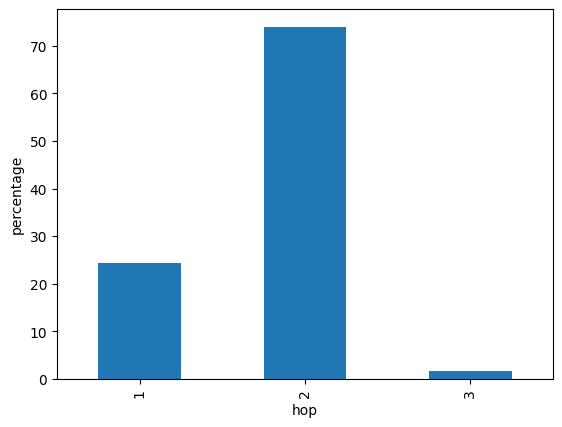

In [39]:
hop_pct = train_merged_df_filtered["hop"].value_counts(normalize=True).sort_index() * 100
hop_pct.plot(kind="bar")
plt.ylabel("percentage")

Sources

Text(0, 0.5, 'percentage')

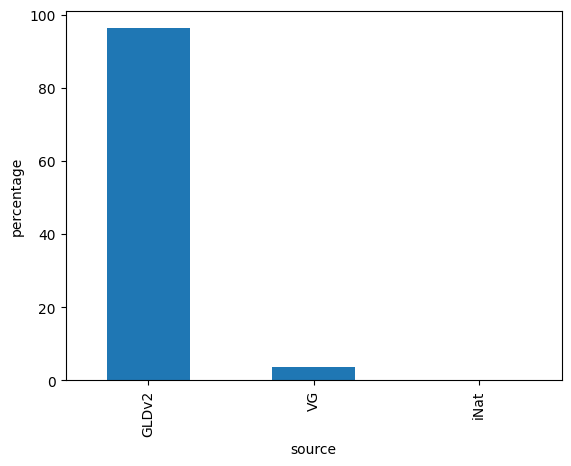

In [40]:
source_pct = train_merged_df_filtered["source"].value_counts(normalize=True).sort_index() * 100
source_pct.plot(kind="bar")
plt.ylabel("percentage")

In [41]:
len(train_df.question_id.unique())

3085697

In [42]:
len(train_ann_df.question_id.unique())

3085697

In [43]:
nums = [f"{i:03d}" for i in range(500)]
print(", ".join(nums))

000, 001, 002, 003, 004, 005, 006, 007, 008, 009, 010, 011, 012, 013, 014, 015, 016, 017, 018, 019, 020, 021, 022, 023, 024, 025, 026, 027, 028, 029, 030, 031, 032, 033, 034, 035, 036, 037, 038, 039, 040, 041, 042, 043, 044, 045, 046, 047, 048, 049, 050, 051, 052, 053, 054, 055, 056, 057, 058, 059, 060, 061, 062, 063, 064, 065, 066, 067, 068, 069, 070, 071, 072, 073, 074, 075, 076, 077, 078, 079, 080, 081, 082, 083, 084, 085, 086, 087, 088, 089, 090, 091, 092, 093, 094, 095, 096, 097, 098, 099, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 

## Create a Sample for Evaluation

In [44]:
qa_ids_top_1000 = train_merged_df_filtered[train_merged_df_filtered["source"] != "VG"]["qa_id"].value_counts().head(1000).index.tolist()

In [45]:
filtered_df = train_merged_df_filtered[
    train_merged_df_filtered["qa_id"].isin(qa_ids_top_1000)
]

In [44]:
sampled_df = (
    filtered_df
    .groupby("qa_id", group_keys=False)
    .apply(lambda x: x.sample(n=2, random_state=42))
)

In [45]:
vg_images_sample = sampled_df[sampled_df["source"] == "VG"]

In [46]:
vg_images_sample["image_url"].iloc[0]

'https://cs.stanford.edu/people/rak248/VG_100K_2/3474.jpg'

In [47]:
import os
import requests
from tqdm import tqdm

images_path = "/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images_vg"
os.makedirs(images_path, exist_ok=True)

headers = {"User-Agent": "Mozilla/5.0"}

for _, row in tqdm(vg_images_sample.iterrows(), total=len(vg_images_sample)):
    url = row["image_url"]
    name = row["image_name"]
    save_path = os.path.join(images_path, name)

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        with open(save_path, "wb") as f:
            f.write(response.content)

    except Exception as e:
        print(f"failed: {url} | {e}")

100%|██████████| 24/24 [00:11<00:00,  2.08it/s]


In [48]:
sampled_df.source.value_counts()

source
GLDv2    1976
VG         24
Name: count, dtype: int64

In [49]:
sampled_df[sampled_df["source"] == "GLDv2"].iloc[0]["image_name"]

'GLDv2_f3c5b035298724f4.jpg'

In [50]:
sampled_df[sampled_df["source"] == "GLDv2"].iloc[0]["image_url"]

'http://upload.wikimedia.org/wikipedia/commons/c/c2/Kolobrzeg_von_Braunschweig_palace_2010-05.jpg'

In [51]:
sampled_df

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url,...,has_scene_graph,entity_id,entity_name,route,property_id,property_label,correct_answer,lower_question,lower_answer,qa_id
544598,GLDv2_f3c5b035298724f4,GLDv2_f3c5b035298724f4.jpg,GLDv2,,4355164,What continent is this house in?,"[Europe, South America, Africa, Antarctica]","[1, 0, 0, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...,...,False,Q11814737,Braunschweig Palace in Kołobrzeg,"[Q11814737, Q46]",P30,continent,Europe,what continent is this house in?,europe,16
1334928,GLDv2_928ab48f375822be,GLDv2_928ab48f375822be.jpg,GLDv2,,3529533,What continent is this house in?,"[Europe, Australia, Asia, South America]","[1, 0, 0, 0]",[0],https://upload.wikimedia.org/wikipedia/commons...,...,False,Q19255988,Casa Claramunt,"[Q19255988, Q46]",P30,continent,Europe,what continent is this house in?,europe,16
496299,GLDv2_be12df6a0886ea23,GLDv2_be12df6a0886ea23.jpg,GLDv2,,3959163,What country is this structure located in?,"[Russia, Somalia, Central African Rep, Dominica]","[1, 0, 0, 0]","[0, 3, 8, 17]",https://upload.wikimedia.org/wikipedia/commons...,...,False,Q4227480,Kokui Tower,"[Q4227480, Q159]",P17,country,Russia,what country is this structure located in?,russia,17
376066,GLDv2_69095ddca07c5772,GLDv2_69095ddca07c5772.jpg,GLDv2,,2982549,What country is this structure located in?,"[Russia, Thailand, Bhutan, Japan]","[1, 0, 0, 0]","[0, 3, 8, 17]",https://upload.wikimedia.org/wikipedia/commons...,...,False,Q4456154,Terrace-pier,"[Q4456154, Q159]",P17,country,Russia,what country is this structure located in?,russia,17
705924,GLDv2_5242c8efe5965386,GLDv2_5242c8efe5965386.jpg,GLDv2,,2600142,On which continent is this Rathaus located?,"[Europe, South America, Asia, North America]","[1, 0, 0, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...,...,False,Q1514829,Rathaus Warburg,"[Q1514829, Q46]",P30,continent,Europe,on which continent is this rathaus located?,europe,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114095,GLDv2_390c62eedc4c8601,GLDv2_390c62eedc4c8601.jpg,GLDv2,,2063797,Which country can this house be found in?,"[United States, Netherlands, Micronesia, Belgium]","[1, 0, 0, 0]","[0, 3, 8, 17]",https://upload.wikimedia.org/wikipedia/commons...,...,False,Q3066129,Edgar Allan Poe House and Museum,"[Q3066129, Q30]",P17,country,United States,which country can this house be found in?,united states,590983
2945819,GLDv2_53481aa24f1fa3e6,GLDv2_53481aa24f1fa3e6.jpg,GLDv2,,2618958,What is the church’s diocese?,"[Roman Catholic Diocese of Litoměřice, Salerno...","[1, 0, 0, 0]",[18],http://upload.wikimedia.org/wikipedia/commons/...,...,False,Q20428035,Church of the Exaltation of the Holy Cross in ...,"[Q20428035, Q569885]",P708,diocese,Roman Catholic Diocese of Litoměřice,what is the church’s diocese?,roman catholic diocese of litoměřice,730516
2931140,GLDv2_1aba9564fa0b4826,GLDv2_1aba9564fa0b4826.jpg,GLDv2,,1185387,What is the church’s diocese?,"[Roman Catholic Diocese of Litoměřice, Zaragoz...","[1, 0, 0, 0]",[18],https://upload.wikimedia.org/wikipedia/commons...,...,False,Q18718621,Church of the Assumption of the Virgin Mary,"[Q18718621, Q569885]",P708,diocese,Roman Catholic Diocese of Litoměřice,what is the church’s diocese?,roman catholic diocese of litoměřice,730516
2938988,GLDv2_10924f862bd18543,GLDv2_10924f862bd18543.jpg,GLDv2,,790964,What diocese does this church belong to?,"[Roman Catholic Diocese of Litoměřice, Bishopr...","[1, 0, 0, 0]",[18],https://upload.wikimedia.org/wikipedia/commons...,...,False,Q21034349,Church of Saint James the Greater,"[Q21034349, Q569885]",P708,diocese,Roman Catholic Diocese of Litoměřice,what diocese does this church belong to?,roman catholic diocese of litoměřice,737314


## Merging Sample DF with updated paths

### GLDV2

Loading report

In [72]:
gldv2_full_report_path = "/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/gldv2_full_report.csv"

In [73]:
gldv2_full_report_df = pd.read_csv(gldv2_full_report_path)

In [74]:
gldv2_full_report_df.head()

,relative_path,cleaned_image_name
0,images_467/e/f/8/ef8e2869f0566476.jpg,ef8e2869f0566476.jpg
1,images_467/e/f/8/ef8429a0c5e116c0.jpg,ef8429a0c5e116c0.jpg
2,images_467/e/f/8/ef8f30c769dc059c.jpg,ef8f30c769dc059c.jpg
3,images_467/e/f/8/ef896c4bf66fa4b5.jpg,ef896c4bf66fa4b5.jpg
4,images_467/e/f/8/ef84b6a4a36e6f1c.jpg,ef84b6a4a36e6f1c.jpg


Filtering samples from GLDv2

In [75]:
gldv2_sampled_df = sampled_df[sampled_df["source"] == "GLDv2"]

In [76]:
gldv2_sampled_df["cleaned_image_name"] = gldv2_sampled_df["image_name"].apply(lambda image_name: image_name.replace("GLDv2_", ""))

/tmp/ipykernel_569675/2115725815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gldv2_sampled_df["cleaned_image_name"] = gldv2_sampled_df["image_name"].apply(lambda image_name: image_name.replace("GLDv2_", ""))


In [77]:
gldv2_sampled_df.head()

,image_id,image_name,source,image_path,question_id,question,answers,correct,categories,image_url,...,entity_id,entity_name,route,property_id,property_label,correct_answer,lower_question,lower_answer,qa_id,cleaned_image_name
544598,GLDv2_f3c5b035298724f4,GLDv2_f3c5b035298724f4.jpg,GLDv2,,4355164,What continent is this house in?,"[Europe, South America, Africa, Antarctica]","[1, 0, 0, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...,...,Q11814737,Braunschweig Palace in Kołobrzeg,"[Q11814737, Q46]",P30,continent,Europe,what continent is this house in?,europe,16,f3c5b035298724f4.jpg
1334928,GLDv2_928ab48f375822be,GLDv2_928ab48f375822be.jpg,GLDv2,,3529533,What continent is this house in?,"[Europe, Australia, Asia, South America]","[1, 0, 0, 0]",[0],https://upload.wikimedia.org/wikipedia/commons...,...,Q19255988,Casa Claramunt,"[Q19255988, Q46]",P30,continent,Europe,what continent is this house in?,europe,16,928ab48f375822be.jpg
496299,GLDv2_be12df6a0886ea23,GLDv2_be12df6a0886ea23.jpg,GLDv2,,3959163,What country is this structure located in?,"[Russia, Somalia, Central African Rep, Dominica]","[1, 0, 0, 0]","[0, 3, 8, 17]",https://upload.wikimedia.org/wikipedia/commons...,...,Q4227480,Kokui Tower,"[Q4227480, Q159]",P17,country,Russia,what country is this structure located in?,russia,17,be12df6a0886ea23.jpg
376066,GLDv2_69095ddca07c5772,GLDv2_69095ddca07c5772.jpg,GLDv2,,2982549,What country is this structure located in?,"[Russia, Thailand, Bhutan, Japan]","[1, 0, 0, 0]","[0, 3, 8, 17]",https://upload.wikimedia.org/wikipedia/commons...,...,Q4456154,Terrace-pier,"[Q4456154, Q159]",P17,country,Russia,what country is this structure located in?,russia,17,69095ddca07c5772.jpg
705924,GLDv2_5242c8efe5965386,GLDv2_5242c8efe5965386.jpg,GLDv2,,2600142,On which continent is this Rathaus located?,"[Europe, South America, Asia, North America]","[1, 0, 0, 0]",[0],http://upload.wikimedia.org/wikipedia/commons/...,...,Q1514829,Rathaus Warburg,"[Q1514829, Q46]",P30,continent,Europe,on which continent is this rathaus located?,europe,36,5242c8efe5965386.jpg


In [78]:
gldv2_sampled_merged_df = gldv2_sampled_df.merge(gldv2_full_report_df, on="cleaned_image_name", how="inner")

In [85]:
gldv2_sampled_merged_df["full_path"] = gldv2_sampled_merged_df["relative_path"].apply(lambda relative_path: os.path.join("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images", relative_path))

In [87]:
gldv2_sampled_merged_df["full_path"].iloc[0]

'/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images/images_476/f/3/c/f3c5b035298724f4.jpg'

### VG

In [80]:
vg_sampled_df = sampled_df[sampled_df["source"] == "VG"]

In [82]:
vg_sampled_df["full_path"] = vg_sampled_df["image_name"].apply(lambda image_name: os.path.join("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images_vg", image_name))

/tmp/ipykernel_569675/3691494893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vg_sampled_df["full_path"] = vg_sampled_df["image_name"].apply(lambda image_name: os.path.join("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images_vg", image_name))


In [84]:
vg_sampled_df["full_path"].iloc[0]

'/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/images_vg/VG_3474.jpg'

## Appending sample datasets

In [30]:
pd.concat([gldv2_sampled_merged_df, vg_sampled_df]).to_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/sample_reasonvqa.pkl")

NameError: name 'gldv2_sampled_merged_df' is not defined

### Standardizing vars

In [6]:
reasonvqa_df = pd.read_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/sample_reasonvqa.pkl")

Fixing paths and answer

In [7]:
reasonvqa_df.rename(columns={"question_id": "uid", "full_path": "image", "lower_answer": "answer"}, inplace=True)

In [8]:
reasonvqa_df["image_path"] = reasonvqa_df["image"]

Fixing rationale and cot

In [9]:
reasonvqa_df["rationale"] = ""
reasonvqa_df["cot"] = ""

Fixing choices

In [10]:
reasonvqa_df["choices"] = reasonvqa_df["answers"].apply(lambda answers: "; ".join(answers))
reasonvqa_df["choices"] = reasonvqa_df["choices"].str.lower()

In [11]:
import string

def format_idx_choices(choices):
    items = [c.strip() for c in choices.split(";")]
    letters = string.ascii_uppercase

    idx_choices = "\n".join(
        f"({letters[i]}) {item}" for i, item in enumerate(items)
    )

    return idx_choices

def format_choices(choices):
    choices_lower = [choice.lower() for choice in choices]
    
    choices_str = "; ".join(choices_lower)

    return {"str": choices_str, "ls": choices_lower}

Create incorrect answer

In [12]:
import random

def get_incorrect_answer(row):
    answers = row["answers"]
    correct = row["answer"]

    # normalize for comparison
    if isinstance(correct, str):
        correct_cmp = correct.lower()
        answers_cmp = [a.lower() if isinstance(a, str) else a for a in answers]
    else:
        correct_cmp = correct
        answers_cmp = answers

    # filter out correct answer
    incorrect_candidates = [
        a for a, a_cmp in zip(answers, answers_cmp) if a_cmp != correct_cmp
    ]

    if not incorrect_candidates:
        return None

    return random.choice(incorrect_candidates).lower()

reasonvqa_df["incorrect_answer"] = reasonvqa_df.apply(get_incorrect_answer, axis=1)

In [13]:
reasonvqa_df["idx_choices"] = reasonvqa_df["choices"].apply(lambda choices: format_idx_choices(choices))

### Creating correct/wrong edit and eval samples

In [14]:
# first instance per qa_id
correct_edit_df = reasonvqa_df.drop_duplicates(subset="qa_id", keep="first")
wrong_edit_df = correct_edit_df.copy()

# last instance per qa_id
eval_df = reasonvqa_df.drop_duplicates(subset="qa_id", keep="last")

In [15]:
all_qa_ids = eval_df["qa_id"].to_list()

In [16]:
wrong_edit_df["answer"] = wrong_edit_df["incorrect_answer"]

In [17]:
formatted_cols = ["uid", "image", "image_path", "question", "answer", "rationale", "cot", "choices", "idx_choices", "qa_id"]

In [117]:
correct_edit_df[formatted_cols].to_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/rvqa_correct_edit_df.pkl")

In [118]:
wrong_edit_df[formatted_cols].to_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/rvqa_wrong_edit_df.pkl")

In [119]:
eval_df[formatted_cols].to_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/eval_df.pkl")

## Loading Datasets

In [7]:
correct_edit_df = pd.read_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/rvqa_correct_edit_df.pkl")
wrong_edit_df = pd.read_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/rvqa_wrong_edit_df.pkl")
eval_df = pd.read_pickle("/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/eval_df.pkl")

In [15]:
import os
import shutil

def copy_images_from_df(df, dst_dir):
    """
    Copy images from df['image_path'] to dst_dir keeping same filenames
    only copies if file does not already exist
    """
    os.makedirs(dst_dir, exist_ok=True)

    for path in tqdm(df["image_path"]):
        if not isinstance(path, str) or not os.path.exists(path):
            continue

        filename = os.path.basename(path)
        dst_path = os.path.join(dst_dir, filename)

        if os.path.exists(dst_path):
            continue  # skip if already copied

        shutil.copy2(path, dst_path)

In [18]:
copy_images_from_df(correct_edit_df, "/home/sgw3fy/jobs/standard_shortcut/projects/model_editing/datasets/reasonvqa/sample_images")

100%|██████████| 1000/1000 [19:20<00:00,  1.16s/it]


In [10]:
correct_edit_df

,uid,image,image_path,question,answer,rationale,cot,choices,idx_choices,qa_id
0,4355164,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,What continent is this house in?,europe,-,-,europe; south america; africa; antarctica,(A) europe\n(B) south america\n(C) africa\n(D)...,16
2,3959163,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,What country is this structure located in?,russia,-,-,russia; somalia; central african rep; dominica,(A) russia\n(B) somalia\n(C) central african r...,17
4,2600142,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,On which continent is this Rathaus located?,europe,-,-,europe; south america; asia; north america,(A) europe\n(B) south america\n(C) asia\n(D) n...,36
6,1857451,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,What country is this church in?,czech republic,-,-,czech republic; singapore; saudi arabia; nauru,(A) czech republic\n(B) singapore\n(C) saudi a...,67
8,4424548,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,Who is the head of government of the successor...,petr fiala,-,-,petr fiala; fredrik reinfeldt; edmund barton; ...,(A) petr fiala\n(B) fredrik reinfeldt\n(C) edm...,80
...,...,...,...,...,...,...,...,...,...,...
2013033,4595167,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,What is the area of the original country of th...,330803,-,-,330803; 354001; 491657; 294470,(A) 330803\n(B) 354001\n(C) 491657\n(D) 294470,225413
3032598,4462157,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,Where was the inventor of the road vehicle bur...,zhalan cemetery,-,-,zhalan cemetery; switzerland; poland; wales,(A) zhalan cemetery\n(B) switzerland\n(C) pola...,225469
2275942,4508068,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,When was the motor vehicle invented?,1884,-,-,1884; 1879; 1890; 1875,(A) 1884\n(B) 1879\n(C) 1890\n(D) 1875,225485
3044023,4620192,/home/sgw3fy/jobs/standard_shortcut/projects/m...,/home/sgw3fy/jobs/standard_shortcut/projects/m...,When did the inventor of the motor vehicle die?,1688,-,-,1688; 1690; 1679; 1693,(A) 1688\n(B) 1690\n(C) 1679\n(D) 1693,225488
